In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("D:\PROGRAMING\ML\ML-House Price\data\house_prices_dataset.csv")

In [3]:
df.head()

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903


In [4]:
df.isnull().sum()

square_feet             0
num_rooms               0
age                     0
distance_to_city(km)    0
price                   0
dtype: int64

In [5]:
print(f"Dataset shape: {df.shape} ")
print(f"Dataset dimension: {df.ndim} ")

Dataset shape: (10000, 5) 
Dataset dimension: 2 


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB


In [7]:
df.describe()

,square_feet,num_rooms,age,distance_to_city(km),price
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1999.147496,4.49510,49.516900,15.362148,263011.571609
std,501.021194,1.71116,28.992336,8.325101,98336.945117
min,500.000000,2.00000,0.000000,1.000161,-95613.138249
25%,1663.704735,3.00000,24.000000,8.121636,196791.510684
50%,1998.702512,4.00000,49.000000,15.403146,262497.361236
75%,2335.540444,6.00000,75.000000,22.447530,330445.581908
max,3963.118853,7.00000,99.000000,29.993892,660168.255648


In [8]:
df.duplicated().sum()

0

This upper code till now tells us the basic description of our dataset , here we were finding no. of duplicate rows , missing values etc . got more info like 5-no. summary values , dtype of every feature .

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

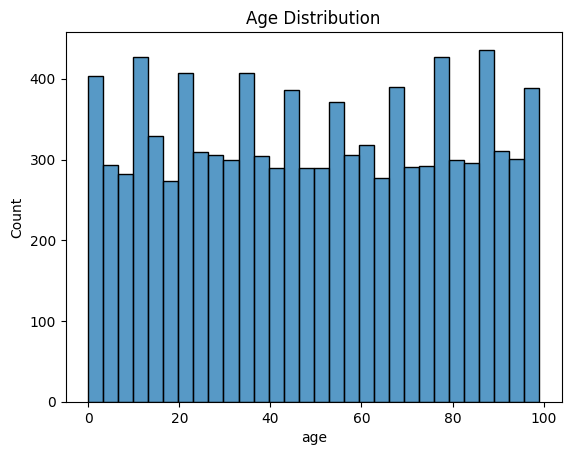

In [10]:
plt.figure()
sns.histplot(data=df["age"],bins=30)
plt.title("Age Distribution")
plt.show()

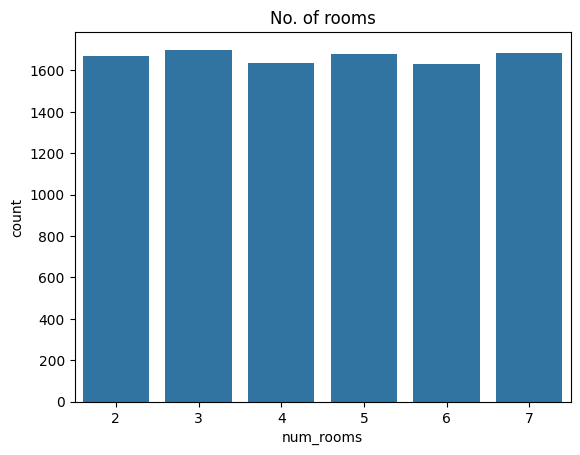

In [11]:
plt.figure()
sns.countplot(data=df,x="num_rooms")
plt.title("No. of rooms")
plt.show()

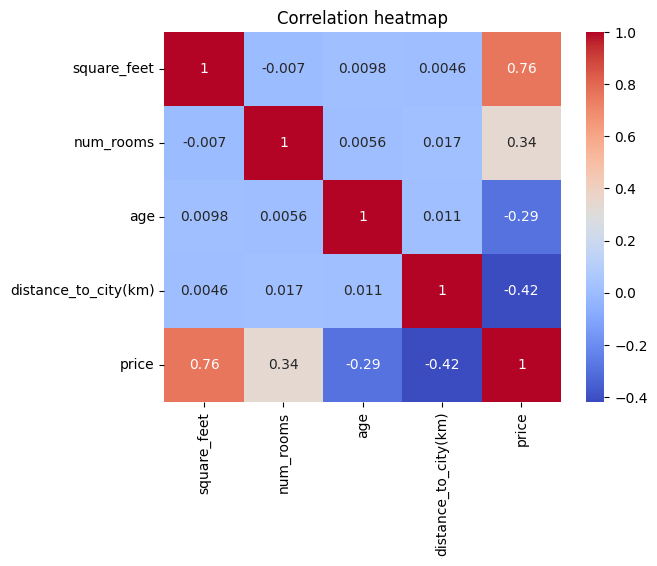

In [12]:
plt.figure()
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

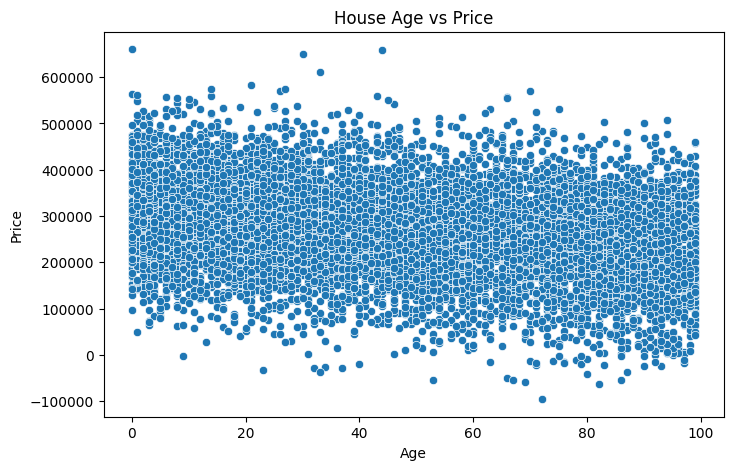

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="age", y="price")
plt.title("House Age vs Price")
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()

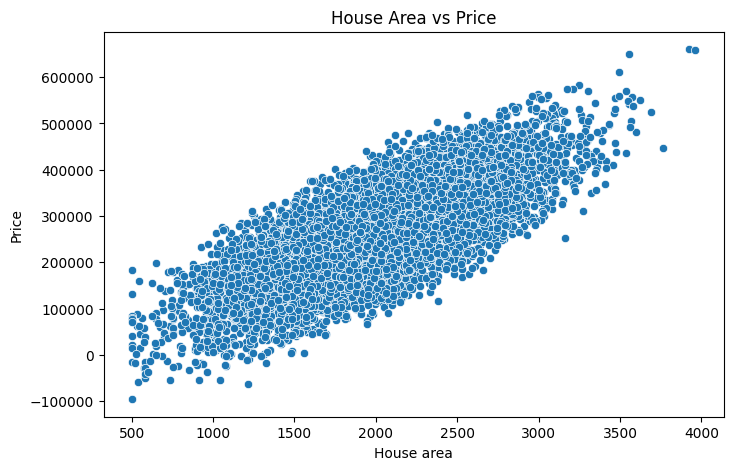

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="square_feet", y="price")
plt.title("House Area vs Price")
plt.xlabel("House area")
plt.ylabel("Price")
plt.show()

Here above we have performed EDA also called graphical analysis which gives us more insight about our data like its distribution , skewness , relation to price feature etc.

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X = df[["square_feet","num_rooms","age","distance_to_city(km)"]]
y = df[["price"]]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
standard_scaler = StandardScaler()
X_train[["square_feet","num_rooms","age","distance_to_city(km)"]] = standard_scaler.fit_transform(X_train[["square_feet","num_rooms","age","distance_to_city(km)"]] )
X_test[["square_feet","num_rooms","age","distance_to_city(km)"]] = standard_scaler.transform(X_test[["square_feet","num_rooms","age","distance_to_city(km)"]] )

In [19]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [20]:
model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)
print(pred.astype(int))

mae = mean_absolute_error(y_test,pred)
mse = mean_squared_error(y_test,pred)

print("MAE of Linear model is :",mae)
print("MSE of Linear model is : ",mse)

[[316636]
 [245793]
 [222084]
 ...
 [261253]
 [254935]
 [204914]]
MAE of Linear model is : 15596.120539083639
MSE of Linear model is :  386443817.4602803


In [21]:
model = Lasso()
model.fit(X_train,y_train)

pred = model.predict(X_test)
print(pred.astype(int))

mae = mean_absolute_error(y_test,pred)
mse = mean_squared_error(y_test,pred)

print("MAE of Lasso model is :",mae)
print("MSE of Lasso model is : ",mse)


[316638 245792 222085 ... 261253 254936 204915]
MAE of Lasso model is : 15596.059608070835
MSE of Lasso model is :  386443453.2465764


In [22]:
model = Ridge()
model.fit(X_train,y_train)

pred = model.predict(X_test)
print(pred.astype(int))

mae = mean_absolute_error(y_test,pred)
mse = mean_squared_error(y_test,pred)

print("MAE of Ridge model is :",mae)
print("MSE of Ridge model is : ",mse)

[[316630]
 [245795]
 [222089]
 ...
 [261253]
 [254936]
 [204922]]
MAE of Ridge model is : 15595.826744147567
MSE of Ridge model is :  386445864.4027144


Among Linear Regression, Lasso, and Ridge, Ridge Regression performed the best because it achieved the lowest MAE and the lowest MSE. This indicates that it produced the smallest average prediction error and handled large prediction errors more effectively than the other models

In [23]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=1.0,l1_ratio=0.5,random_state=42)
model.fit(X_train,y_train)

pred = model.predict(X_test)

print(pred.astype(int))

mae = mean_absolute_error(y_test,pred)
mse = mean_squared_error(y_test,pred)

print("MAE of Elastic net model is :",mae)
print("MSE of Elastic net model is : ",mse)

[299288 251596 235903 ... 262182 257963 224653]
MAE of Elastic net model is : 30289.686628269414
MSE of Elastic net model is :  1444245286.7752483


In [24]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

pred = model.predict(X_test)

print(pred.astype(int))

mae = mean_absolute_error(y_test,pred)
mse = mean_squared_error(y_test,pred)

print("MAE of Random forest regressor model is :",mae)
print("MSE of Random forest regressor model is : ",mse)

C:\Users\NINAD\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[376943 244124 225945 ... 262939 248506 211957]
MAE of Random forest regressor model is : 18013.929201823474
MSE of Random forest regressor model is :  508887992.0621685


In [25]:
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

pred = model.predict(X_test)

print(pred.astype(int))

mae = mean_absolute_error(y_test,pred)
mse = mean_squared_error(y_test,pred)

print("MAE of Extra tree regressor model is :",mae)
print("MSE of Extra Tree regressor model is : ",mse)

C:\Users\NINAD\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[369137 239905 219548 ... 263029 257207 209939]
MAE of Extra tree regressor model is : 17862.799350534395
MSE of Extra Tree regressor model is :  500782302.5379563


In [26]:
from sklearn.ensemble import AdaBoostRegressor

model = AdaBoostRegressor(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

pred = model.predict(X_test)

print(pred.astype(int))

mae = mean_absolute_error(y_test,pred)
mse = mean_squared_error(y_test,pred)

print("MAE of AdaBoost Regressor model is :",mae)
print("MSE of AdaBoost Regressor model is : ",mse)

C:\Users\NINAD\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[354644 231590 210754 ... 259091 223610 193628]
MAE of AdaBoost Regressor model is : 24256.940263803797
MSE of AdaBoost Regressor model is :  929132751.201013


In [27]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train,y_train)

pred = model.predict(X_test)
print(pred.astype(int))

mae = mean_absolute_error(y_test,pred)
mse = mean_squared_error(y_test,pred)

print("MAE of Gradient Boosting regressor model is :",mae)
print("MSE of Gradient Boosting regressor model is : ",mse)

C:\Users\NINAD\AppData\Roaming\Python\Python311\site-packages\sklearn\ensemble\_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[326716 250293 218604 ... 265844 250164 215413]
MAE of Gradient Boosting regressor model is : 16628.489424356703
MSE of Gradient Boosting regressor model is :  436777366.9323522


In [28]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(pred)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)

print("MAE of XGBoost regressor model is :", mae)
print("MSE of XGBoost regressor model is :", mse)

[324217.56 241103.53 224526.03 ... 256941.14 250595.45 203861.28]
MAE of XGBoost regressor model is : 16935.032119691306
MSE of XGBoost regressor model is : 455901789.29141444


In [29]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(pred)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)

print("MAE of cat boost regressor model is :", mae)
print("MSE of cat boost regressor model is :", mse)

[311290.41236029 250121.32606764 213818.12426456 ... 262281.75895115
 251998.44104584 210966.7256996 ]
MAE of cat boost regressor model is : 16182.466550823796
MSE of cat boost regressor model is : 415408632.46876067


In [30]:
from sklearn.linear_model import SGDRegressor

model = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(pred)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)


print("MAE of SGD regressor model is :", mae)
print("MSE of SGD regressor model is :", mse)

[316351.20425549 245950.52295709 221892.50899642 ... 261466.80339663
 254889.32779485 205107.30152606]
MAE of SGD regressor model is : 15603.218872407058
MSE of SGD regressor model is : 386475054.02509826


C:\Users\NINAD\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Out of all this models the ridge is the best performing hence lets apply a streamlit UI on it . 

In [31]:
from sklearn.linear_model import Ridge
import joblib

model = Ridge()
model.fit(X_train, y_train)

joblib.dump(model, "model/ridge_model.pkl")

['model/ridge_model.pkl']